# Corpus Analysis

At this stage in the term, you'll want to subject your own transcription and metadata to various kinds of comparison with some larger corpus. You may use this notebook as a starting point, or to inspire approaches of your own.

## XML Corpus Extraction

If the corpus you will be using is available in plaintext format, see [`corpora.ipynb`](https://github.com/langeslag/words-methods/blob/main/corpora.ipynb) on how to load it into lists of tokens (just keep in mind you may want to load each document as a continuous string for some `scikit-learn` applications; see below). In this notebook, let's assume you want to extract data from an XML corpus instead, using `lxml.etree`. Once again we'll use [ECHOE](https://github.com/ECHOEProject/echoe) as an example.

In [1]:
import os,glob,matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from git import Repo
from lxml import etree
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [2]:
remote = 'https://github.com/ECHOEProject/echoe.git'
local = 'echoe'
# Only clone if the target folder doesn't already exist:
if not(os.path.exists(local)):
    repo = Repo.clone_from(remote, local)
# Else, just update the working copy from remote:
else:
    repo = Repo(local)
    assert isinstance(repo, Repo)
    repo.remotes.origin.pull()
assert not repo.bare


In [3]:
# Create a dict with characters we want replaced:
substitutions = {
    'á': 'a',
    'ǽ': 'æ',
    'é': 'e',
    'ę': 'æ',
    'í': 'i',
    'ó': 'o',
    'ú': 'u',
    'ý': 'y',
    'ẏ': 'y',
    'ƿ': 'w',
    'ſ': 's',
    '': 's', # Using the glyph for descending s, instead of the unicode key point
    'v': 'u',
    'j': 'i',
    '⁊': 'and',
    '·': '',
    ' ': '',
    '\n': ''
}

# Write a function carrying out the desired operations:
def normalize(token):
    # Lowercase:
    token = token.lower()
    for k,v in substitutions.items():
        # Carry out replacements:
        token = token.replace(k, v)
    return token

# Function to discard unwanted elements from the document tree:
def simplify(branch):
    discard = ['abbr', 'am', 'del', 'sic', 'note']
    query = ['{http://www.tei-c.org/ns/1.0}' + i for i in discard]
    for hit in branch.iter(query):
        hit.getparent().remove(hit)

Thus far in our `lxml` exercises, we have parsed one document at a time. To read in an entire corpus, we'll have to write a function to extract the relevant nodes, so we can apply the function to each document in the corpus. For now, let's assume we just want to extract string tokens, not metadata or chunk-level information.

As noted in [`lxml.etree.ipynb`](https://github.com/langeslag/words-methods/blob/main/lxml.etree.ipynb), there is a complication in the extraction of `<w>`-nodes in ECHOE: where XML hierarchies overlap, it has sometimes been necessary to split a word into two `<w>`-nodes, marked by attributes `@part="I"` for initial or `@part="F"` for final (there was no need in ECHOE to resort to the third value provided by TEI, `M` for medial). In our `parse()` function below, we'll therefore glue such part-words back together.

In [4]:
parser = etree.XMLParser(remove_blank_text=True,resolve_entities=True)

def parse(doc):
    identifier = os.path.basename(doc).replace('.xml', '')
    tokens = []
    tree = etree.parse(doc, parser=parser)
    root = tree.getroot()
    text = root.find('.//{http://www.tei-c.org/ns/1.0}text')
    simplify(text)
    for token in text.iter('{http://www.tei-c.org/ns/1.0}w'):
        # If a word element is marked as the last part of a word, add its text content to the preceding token:
        if token.get('part') == 'F':
            position = len(tokens)-1
            tokens[position] = tokens[position] + normalize(etree.tostring(token, method='text', encoding='unicode'))
        else:
            tokens.append(normalize(etree.tostring(token, method='text', encoding='unicode')))
        # Our downstream analysis actually expects each document to be a single string,
        # so we're abandoning tokenization for now!
        string = ' '.join(tokens)
    return {identifier: string}

In [5]:
corpus = dict()
for file in sorted(glob.glob('echoe/xml/*.xml')):
    corpus.update(parse(file))

In [6]:
corpus['035.04'][:80]

'men þa leofestan her onginð þæt halie gewrit þe com fram heofenan into hierusale'

If you need any kind of metadata from your XML corpus, you can modify the `parse()` function to return a `dict` with keys for all the information you wish to retain.

Given that this course has you producing your own XML document, you will want to bring your own document into the fold. (This notebook will use a student transcription not included in the repository; you can supply your own.) Depending on your needs, you can either keep it in its own container or merge it into a combined corpus. Most things involving tables or graphs are best served by the latter approach. Just remember if you've transcribed a text that is already represented in your corpus, you may or may not want to remove the duplicate document from your corpus, depending on whether you think it will spoil your results.

Of course for an apples-to-apples-comparison, you could read in your document using the `parse()` function defined above, discarding all metadata. But you may yet find reason to make use of your metadata. For instance, you can use part-of-speech or lemma annotations to make modest assumptions about identically spelled words in the larger corpus answering to the same descriptions. By identifying all the forms for a given lemma in your own document, for instance, you can run analyses on that same lemma across the corpus, with the understanding that you are probably missing out on occurrences whose spelling is not attested in your smaller lemmatized sample. So let's first read in your document preserving the metadata, and then add just the tokens to the larger corpus.

In [7]:
filename = '../projects/example.xml'
tree = etree.parse(filename, parser=parser)
root = tree.getroot()
text = root.find('.//{http://www.tei-c.org/ns/1.0}text')
simplify(text)

my_doc_data = []
for i in text.iter('{http://www.tei-c.org/ns/1.0}w'):
    dictionary = dict()
    dictionary['form'] = etree.tostring(i, method='text', encoding='unicode')
    dictionary['norm'] = normalize(dictionary['form'])
    dictionary['pos'] = i.get('pos')
    dictionary['lemma'] = i.get('lemma')
    my_doc_data.append(dictionary)

my_doc_tokens = [i['norm'] for i in my_doc_data]
corpus['my_doc'] = ' '.join(my_doc_tokens)

In [8]:
corpus['my_doc'][:80]

'be mistlican gelimpan gyf hit geweorðe þæt on þeodscype becume healic ungelimp f'

## Evaluation: TF-IDF

With our corpus complete, we can start generating evaluative data.

To start with, we can harness a TF-IDF model to gauge document similarity across the corpus, which we'll then list in a Pandas DataFrame.

TF-IDF stands for "term frequency times inverted document frequency." The first part of this equation relies on the common-sense assumption that a term (i.e. word form) that occurs frequently in a document is informative as to what the document is about, especially if we normalize that value for the length of the document (i.e. divide the number of attestations of a term by the document's total token count). The second part of the equation corrects for the fact that common words, especially function words like "the" and "of" but frequent lexical words as well, are not "what the document is about" even if they are the most frequent. It does this by dividing the total document count by the number of documents containing the term in question.

(To make matters slightly more complex, it takes the logarithm of this division, which takes advantage of the fact that the distribution of absolute word frequencies for all terms in a corpus tends to resemble a power law, and turns these order-of-magnitude numbers into roughly sequential numbers, so instead of IDF scores with lots of zeroes we have human-scale numbers, which is also computationally frugal. For instance, ECHOE has 337 documents, so a term occurring in only one of them has an IDF of 337/1=337, but its logarithm is around 2.5. In modern text corpora, of course, those numbers are a lot higher.)

In the below initialization of the vectorizer, pay particular attention to the argument `max_df`. When we set a float value between `0` and `1` for this argument, we are saying: if a term occurs in this proportion of documents or more, ignore it; thus by setting a value of `0.8`, we are disregarding word forms occurring in eighty percent or more of corpus documents. This is effectively equivalent to manually compiling a list of stop words to exclude from the model, as is often done in NLP tasks; the documentation describes such a setting as excluding "corpus-specific stop words," and the recommended value for this purpose is between `0.7` and `1.0`.

Given that the whole point of TF-IDF is to downweight frequent words, you would think that this model obviates the need to exclude stop words. However, you'll find that leaving `max_df` unspecified (meaning it defaults to `1.0`) makes a great deal of difference, especially once you start asking the model which terms it considers the most important in any given document. This is precisely because downweighting is not the same as excluding. Even so, one has to ask whether the downweighting curve shouldn't be steeper if default settings report that a document is most about a stop word like "and!" Additionally, reliance on a setting like `max_df` raises the question which setting yields the most valid results.

In [9]:
vectorizer = TfidfVectorizer(min_df=1, max_df=0.8)
model = vectorizer.fit_transform(corpus.values())
df = pd.DataFrame(cosine_similarity(model), corpus.keys(), corpus.keys())
df.sort_values('my_doc', ascending=False)

,018.40,018.42,021.27,021.28,032.09,032.11,032.12,032.13,032.17,032.18,...,394.24,394.25,394.26,394.27,394.29,402.bi,402.bii,402.biii,407.a,my_doc
my_doc,0.043881,0.064769,0.082572,0.121230,0.035462,0.025629,0.024640,0.026832,0.020167,0.046236,...,0.081791,0.058940,0.070781,0.049604,0.047430,0.166531,0.125578,0.137768,0.012618,1.000000
331.29,0.048059,0.066018,0.082027,0.122431,0.050145,0.024717,0.025663,0.030253,0.019141,0.044753,...,0.084356,0.057174,0.073312,0.049184,0.047593,0.178545,0.127842,0.154192,0.011765,0.857197
049B.14,0.080779,0.101738,0.090744,0.084308,0.073259,0.052297,0.051982,0.059209,0.035831,0.067751,...,0.078500,0.043519,0.057698,0.040816,0.060683,0.109925,0.057357,0.098322,0.023476,0.457733
186.19e,0.070646,0.109954,0.183388,0.123020,0.068465,0.056432,0.057892,0.061067,0.040856,0.093979,...,0.121267,0.069239,0.084812,0.056590,0.063269,0.084784,0.054582,0.088174,0.022428,0.231779
331.15,0.082944,0.106476,0.141849,0.137971,0.060082,0.059001,0.047087,0.068122,0.038357,0.060120,...,0.116129,0.085788,0.108375,0.075983,0.068895,0.193995,0.085359,0.082046,0.046211,0.186237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309.75,0.025449,0.016140,0.029730,0.026832,0.034286,0.032599,0.035498,0.046317,0.057611,0.028671,...,0.036241,0.016717,0.020311,0.022393,0.040360,0.009977,0.004500,0.048933,0.000000,0.007209
386x.b,0.068357,0.014131,0.030452,0.028136,0.048862,0.059445,0.031977,0.047055,0.024736,0.034603,...,0.028363,0.037867,0.040927,0.021311,0.037408,0.007433,0.007552,0.011797,0.009057,0.004104
319.a,0.017459,0.005587,0.009849,0.024382,0.020000,0.008839,0.023666,0.062215,0.015154,0.004010,...,0.019273,0.008911,0.049039,0.016519,0.000750,0.011380,0.000000,0.000000,0.013020,0.001392
332.19,0.031897,0.028546,0.024446,0.022613,0.045733,0.029000,0.006017,0.033481,0.009949,0.031132,...,0.009127,0.007787,0.005518,0.040112,0.012643,0.058736,0.016886,0.017655,0.008511,0.001072


Judging by this output, `my_doc` is strikingly similar to ECHOE 331.29, inasmuch as the score is nearly twice that of the next highest match. So this is where you conduct your first eyeball comparison, or you can conduct further statistical analysis.

As it happens, ECHOE 331.29 is actually the ECHOE transcription separately transcribed as `my_doc`. The second hit is another manuscript witness to the same text. And so is the third. Success!

Now of course we're curious which terms have proven most "important" to our external document; what is our transcription "about"?

Let's arrange our TF-IDF model as another Pandas DataFrame, this time populating it with the document term scores. We'll sideload the terms themselves as column labels, and the document labels as row labels:


In [10]:
scores = pd.DataFrame(model.toarray(), corpus.keys(), vectorizer.get_feature_names_out())
scores.loc['my_doc'].sort_values(ascending=False)[:20]

hwilum           0.415034
oððon            0.207965
georne           0.197764
geræde           0.197714
gyf              0.190029
fæsten           0.181194
swyðe            0.172119
peninc           0.168702
geomerigendum    0.112468
sece             0.110015
heorðe           0.106819
be               0.100913
hy               0.100900
est              0.100122
sealm            0.098857
neod             0.097192
niniuete         0.095830
æt               0.094500
sy               0.093019
clypige          0.090895
Name: my_doc, dtype: float64

_Hwilum_ "sometimes" is not that remarkable a term, but it occurs fourteen times in the 608 tokens of our document, and that makes it stand out in the IF-TDF formula, but of course only because it doesn't meet our DF exclusion threshold of 80 percent. _Georne_ "gladly" similarly occurs twelve times. _Peninc_ "penny" is striking because it is rare in the homiletic corpus, and "geomerigendum" is unusual across the entire corpus of Old English as a participial form of _geomerian_ "mourn."

## Visualization: TF-IDF

In a TF-IDF model, each document is represented by a vector, i.e. a list of TF-IDF scores, with as many dimensions (i.e. scores) as the corpus has terms; thus the combined vocabulary of the corpus becomes a series of points against which each document is measured. As ECHOE has nearly 36,000 distinct word forms, an unabridged scatter plot of document vectors would require us to see in thousands of dimensions. So what we'll do instead is transform those vectors into just two or three dimensions. The downside of this compromise is that those dimensions lack any identifiable value, beyond each having something to do with the relative frequency of terms in the corpus.

We'll use principal component analysis (PCA), a mathematical model often used for the reduction of noise among the signal:

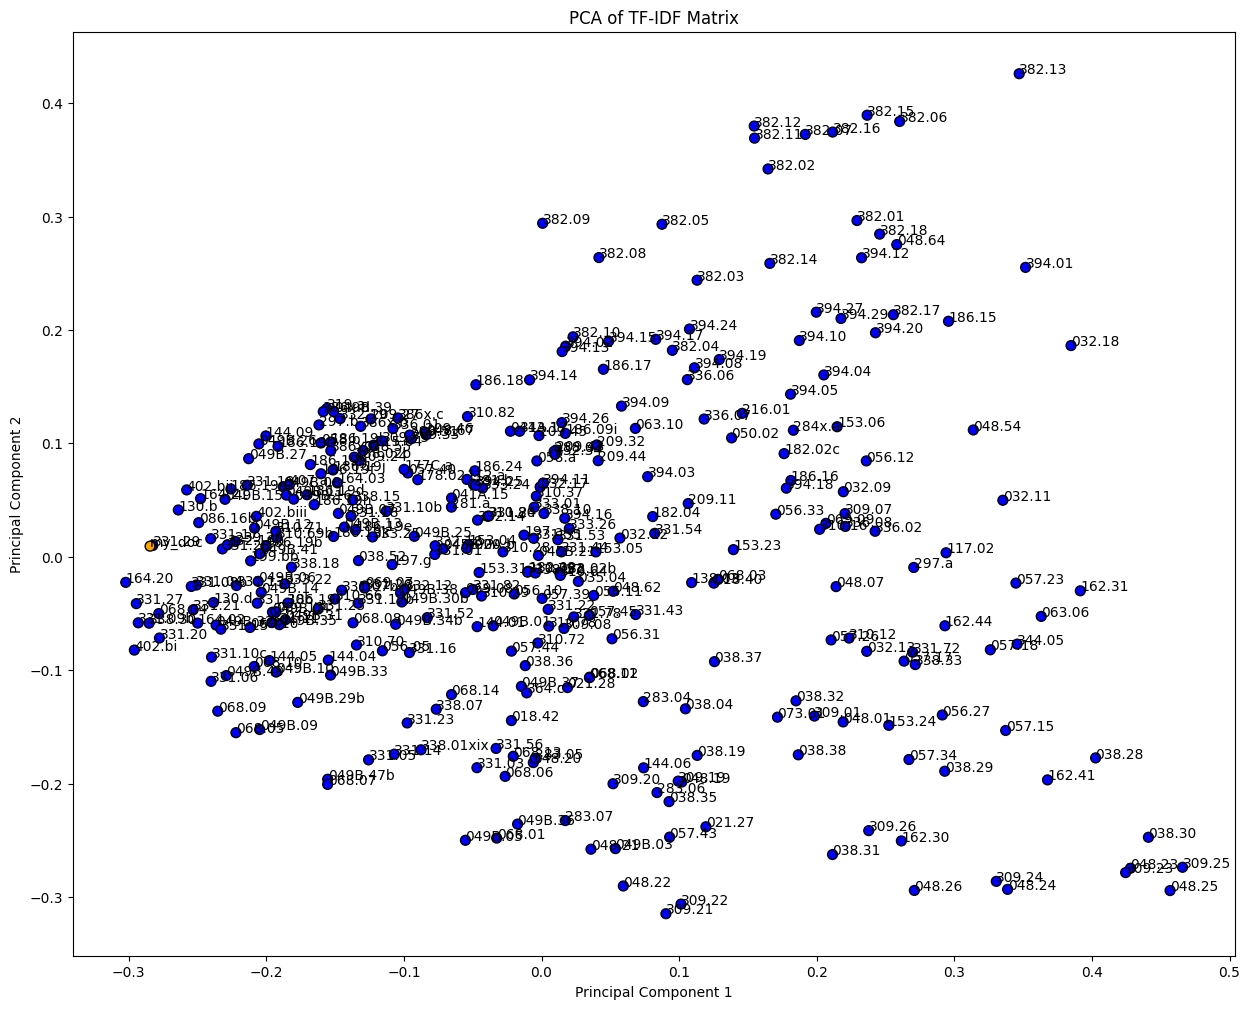

In [11]:
# Instantiate the PCA class with two dimensions:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(model.toarray())
# Visually set our external document apart from ECHOE documents:
colors = ['blue', 'orange']
labels = [0 for i in corpus.keys()]
labels[-1] = 1
plt.figure(figsize=(15, 12))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap=matplotlib.colors.ListedColormap(colors), edgecolor='k', s=50)
for i, txt in enumerate(corpus.keys()):
    plt.annotate(txt, (pca_result[i, 0], pca_result[i, 1]))
plt.title('PCA of TF-IDF Matrix')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

As predicted above, these results leave us curious for the meaning of each axis: apparently our new document scores very near one extreme on one axis, and right in the middle of the other. All we can do is inspect nearby documents and find out for ourselves what they have in common. As in the tabular form above, of course, 331.29 is the closest match because it represents the same manuscript copy of the same composition. The close score of ECHOE 130.b is striking because that document is a rare autograph of Wulfstan, while our external document was likewise written by Wulfstan, so the model supports the reading that these are by the same author. Other nearby documents, such as 86.16b, are likewise Wulfstan's. The remote data points 48.25 and 382.13 are compositions first attested in the Vercelli and Blickling manuscripts, both of which predate Wulfstan.